In [ ]:
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import numpy as np

# Database connection parameters
db_params = {
    'host': '',
    'port': '',
    'database': '',
    'user': '',
    'password': ''
}

# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

# Ensure 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Set the future option to opt-in to the new behavior
pd.set_option('future.no_silent_downcasting', True)

# Replace empty strings with NaN in the 'road_number' column
df_safe_driving['road_number'] = df_safe_driving['road_number'].replace("", np.nan)

# Verify that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

# Verify that the rows with missing values
print(df_safe_driving.isna().sum())

# Print start cleaning
print('\nStarting Cleaning:\n')

# Remove the 'road_number' column
df_safe_driving = df_safe_driving.drop('road_number', axis=1)

# Verify that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())

# Strip whitespace from the 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()

# Print the unique values
print(df_safe_driving['category'].unique())

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('After cleaning there are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('After cleaning there are', missing_count, 'missing values')

df_safe_driving.head()

There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488
eventid                   0
event_start               0
event_end                 0
duration_seconds          0
latitude                  0
longitude                 0
speed_kmh                 0
end_speed_kmh             0
maxwaarde                 0
category                  0
incident_severity         0
is_valid                  0
road_segment_id           0
road_manager_type         0
road_number          964488
road_name                 0
place_name                0
municipality_name         0
road_manager_name         0
dtype: int64

Starting Cleaning:

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_sever

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_name,place_name,municipality_name,road_manager_name
0,5399677,2018-01-20 12:12:44.000,2018-01-20 12:12:50.000,6.0,51.59900,4.800132,62.764416,62.764416,64.373760,SPEED,SP1,True,600892914,G,Kapittelweg,Breda,Breda,Breda
1,5964288,2018-01-20 07:42:17.000,2018-01-20 07:42:34.000,17.0,51.60683,4.716417,43.452290,41.842945,43.452290,SPEED,SP1,True,217204035,G,Beeksestraat,Prinsenbeek,Breda,Breda
2,5732939,2018-01-20 11:42:50.000,2018-01-20 11:42:51.100,1.1,51.58443,4.802168,22.530815,19.312128,0.729033,HARSH CORNERING,HC1,True,600892947,G,Bijster,Breda,Breda,Breda
3,5668204,2018-01-20 16:48:45.600,2018-01-20 16:48:47.300,1.7,51.60423,4.709933,28.968191,27.358849,0.804672,HARSH CORNERING,HC1,True,216203042,G,Heikantsestraat,Prinsenbeek,Breda,Breda
4,5916965,2018-01-20 20:01:38.000,2018-01-20 20:01:48.000,10.0,51.59119,4.744330,41.842945,41.842945,46.670975,SPEED,SP1,True,220200029,G,Aurelia,Breda,Breda,Breda


In [2]:
# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.wind"
df_wind = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

# Checking for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df_wind.isnull().sum().sort_values(ascending=False))

# Print start cleaning
print('\nStarting Cleaning:\n')

# Drop the columns
df_wind = df_wind.drop(columns=['fx_sensor_md_10', 'squall_10'])

# List of columns with missing values
columns_with_missing_values = ['ff_10m_10', 'dd_10', 'ddn_10', 'dd_std_10', 'ddx_10', 
                               'ff_sensor_10', 'ff_10m_std_10', 'fx_10m_10', 'fx_10m_md_10', 'fx_sensor_10']

# Fill missing values with the mean for each column
df_wind[columns_with_missing_values] = df_wind[columns_with_missing_values].fillna(df_wind[columns_with_missing_values].mean())

# Checking for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df_wind.isnull().sum().sort_values(ascending=False))

There are 0 duplicate values
There are 2352646 missing values
squall_10          1098837
fx_sensor_md_10    1098837
fx_sensor_10         15953
fx_10m_md_10         15897
fx_10m_10            15545
ff_10m_std_10        15421
ddx_10               15420
ff_sensor_10         15420
dd_std_10            15418
ddn_10               15351
dd_10                15291
ff_10m_10            15256
LOCATION                 0
altitude                 0
longitude                0
latitude                 0
NAME                     0
dtg                      0
dtype: int64

Starting Cleaning:

There are 0 duplicate values
There are 0 missing values
dtg              0
LOCATION         0
NAME             0
latitude         0
longitude        0
altitude         0
ff_10m_10        0
dd_10            0
ddn_10           0
dd_std_10        0
ddx_10           0
ff_sensor_10     0
ff_10m_std_10    0
fx_10m_10        0
fx_10m_md_10     0
fx_sensor_10     0
dtype: int64


In [3]:
import pandas as pd
from sqlalchemy import create_engine

db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group2',
    'password': 'blockd_2024group2_58'
}

# Create string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create engine
engine = create_engine(conn_string)

def load_data(query, engine):
    """
    Load data from database.
    """
    print(f"Executing query: {query}")
    df = pd.read_sql(query, engine)
    print(f"Loaded {len(df)} rows.")
    return df

# Load data
safe_driving_df = load_data("SELECT * FROM data_lake.safe_driving", engine)
wind_df = load_data("SELECT * FROM data_lake.wind", engine)

def process_safe_driving_data(df):
    """
    Process the safe driving data.
    """
    print("Processing safe driving data...")
    
    # Ensure they are in datetime format
    df['event_start'] = pd.to_datetime(df['event_start'], errors='coerce')
    df['event_end'] = pd.to_datetime(df['event_end'], errors='coerce')
    df['date'] = df['event_start'].dt.date
    
    # Drop columns if they exist
    columns_to_drop = ['event_end', 'road_number']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
    
    # Clean 'category' column
    df['category'] = df['category'].str.strip()
    
    print("Safe driving data processing complete.")
    print(df.info())
    return df

def process_wind_data(df):
    """
    Process the wind data.
    """
    print("Processing wind data...")
    
    # Ensure 'dtg' is in datetime format
    df['dtg'] = pd.to_datetime(df['dtg'], errors='coerce')
    df['date'] = df['dtg'].dt.date
    
    # Drop unnecessary columns
    columns_to_drop = ['dtg', 'LOCATION', 'NAME', 'latitude', 'longitude', 'altitude', 'fx_sensor_md_10', 'squall_10']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
    
    print("Wind data processing complete.")
    print(df.info())
    return df

def merge_datasets(df1, df2):
    """
    Merge the two datasets on the 'date' column.
    """
    print("Merging datasets...")
    merged_df = pd.merge(df1, df2, on='date', how='inner')
    print(f"Merged dataset contains {len(merged_df)} rows.")
    print(merged_df.info())
    return merged_df

# Process data
safe_driving_df = process_safe_driving_data(safe_driving_df)
wind_df = process_wind_data(wind_df)

# Merge datasets
merged_df = merge_datasets(safe_driving_df, wind_df)

# Final display of merged dataframe
print("First few rows of the merged DataFrame:")
print(merged_df.head())

Executing query: SELECT * FROM data_lake.safe_driving
Loaded 964488 rows.
Executing query: SELECT * FROM data_lake.wind
Loaded 1098837 rows.
Processing safe driving data...
Safe driving data processing complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964488 entries, 0 to 964487
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   eventid            964488 non-null  int64         
 1   event_start        964488 non-null  datetime64[ns]
 2   duration_seconds   964488 non-null  float64       
 3   latitude           964488 non-null  float64       
 4   longitude          964488 non-null  float64       
 5   speed_kmh          964488 non-null  float64       
 6   end_speed_kmh      964488 non-null  float64       
 7   maxwaarde          964488 non-null  float64       
 8   category           964488 non-null  object        
 9   incident_severity  964488 non-null  object        
 10  

Sampling data...
Generating correlation matrix...


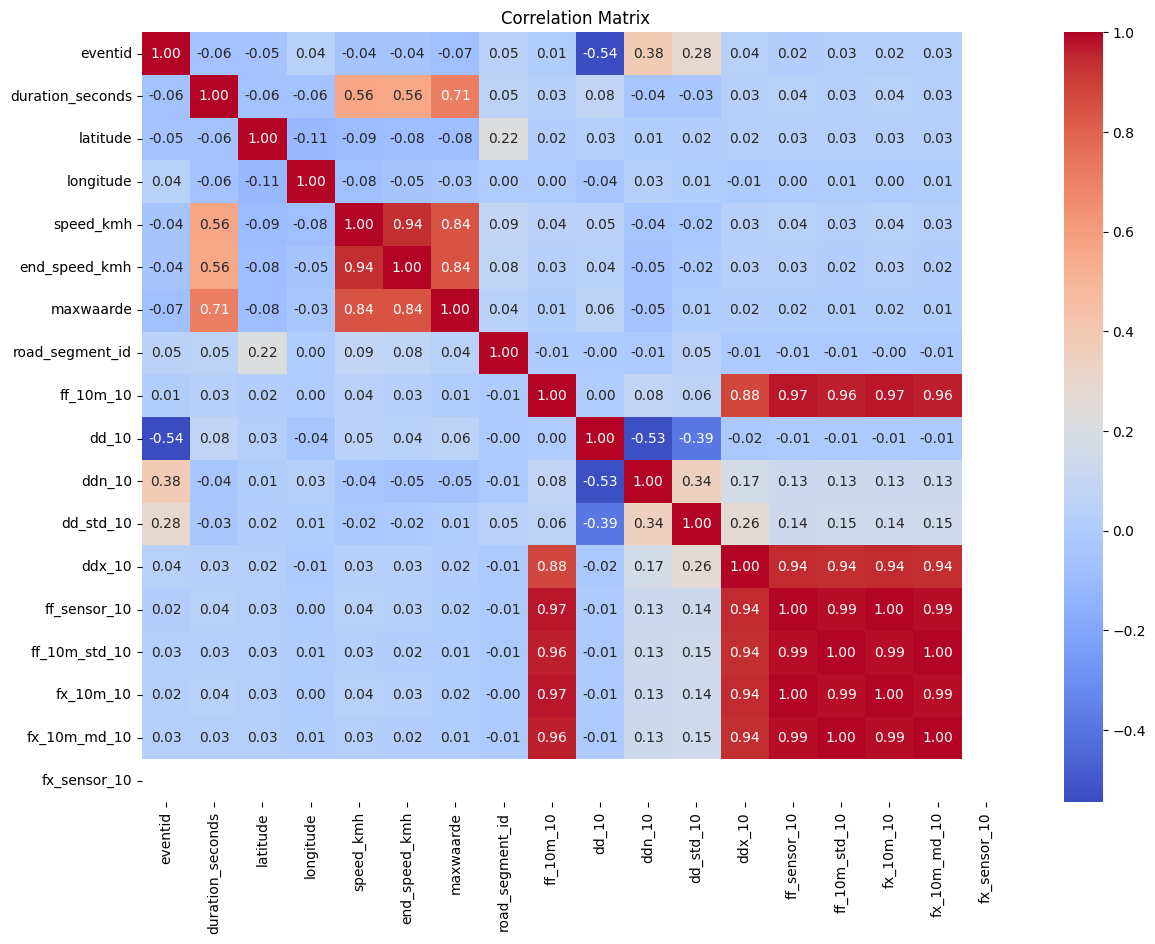

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def display_correlation_matrix(df, sample_size=1000):
    """
    Display correlation matrix for a sample of the dataframe.
    """
    print("Sampling data...")
    sample_df = df.sample(n=sample_size, random_state=1)  # Sample a portion of the data
    numeric_df = sample_df.select_dtypes(include=['float64', 'int64'])
    print("Generating correlation matrix...")
    corr_matrix = numeric_df.corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix')
    plt.show()

display_correlation_matrix(merged_df, sample_size=1000)  # Adjust sample_size as needed